# Gradient Descent vs Stochastic Gradient Descent

## Objective
In this notebook, we will:
- Understand **Gradient Descent (GD)** mathematically and intuitively
- Derive its update rule
- Implement it in Python
- Explore **Stochastic Gradient Descent (SGD)**
- Compare both methods visually

---

## Why Optimization Matters

In machine learning, we aim to minimize a **loss function**:
The Objective FunctionThe Cost Function (or empirical risk) represents the average loss over the entire training set:$$J(\theta) = \frac{1}{n} \sum_{i=1}^{n} L(f(x_i, \theta), y_i)$$This measures how well our model performs across all $n$ samples.The Optimization GoalThe goal of training is to find the optimal parameters $\theta^*$ that minimize this cost:$$\theta^* = \arg\min_\theta J(\theta)$$


$J(\theta)$: The cost function we want to minimize.

$f(x_i, \theta)$: The model's prediction for input $x_i$ given parameters $\theta$.

$L$: The loss function (like Focal Loss or Cross-Entropy) that compares the prediction to the true label $y_i$.

$\arg\min$: The "argument of the minimum"—specifically, the value of $\theta$ that results in the lowest possible value for $J$.

## Gradient Descent

Gradient Descent is an iterative optimization algorithm.

### Key Idea:
- Compute the gradient of the loss function
- Move in the opposite direction of the gradient

### Update Rule:
$$
\theta_{t+1} = \theta_t - \eta \nabla J(\theta_t)
$$


Where:
- \( \eta \): learning rate
- \( \nabla J(\theta) \): gradient

---

### Intuition

- The gradient points in the direction of steepest increase
- We go in the opposite direction → decrease the loss

## Mathematical Derivation

Using first-order Taylor expansion:
$$
J(\theta + \Delta\theta) \approx J(\theta) + \nabla J(\theta)^T \Delta\theta
$$
To minimize the function, we choose:
$$
\Delta\theta = -\eta \nabla J(\theta)
$$
This gives the update rule.

---

## Example: Linear Regression
$$
\nabla J(\theta) = \frac{1}{n} \sum_{i=1}^{n} \nabla L_i(\theta)
$$


In [5]:
import numpy as np 
import matplotlib.pyplot as plt

#synthesis data
np.random.seed(42)
X= 2 * np.random.rand(100,1)
y= 4 + 3 * X + np.random.randn(100,1)
X_b= np.c_[np.ones((100,1)),X]
theta = np.random.randn(2,1)
eta = 0.1
n_iterations = 50

losses_gd = []

def compute_loss(X, y, theta):
    return np.mean((X @ theta - y) ** 2)

for iteration in range(n_iterations): 
    gradients = (2/len(X)) * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients
    losses_gd.append(compute_loss(X_b, y, theta))

print("Theta found by gradient descent:", theta)


Theta found by gradient descent: [[3.91125197]
 [3.03839129]]


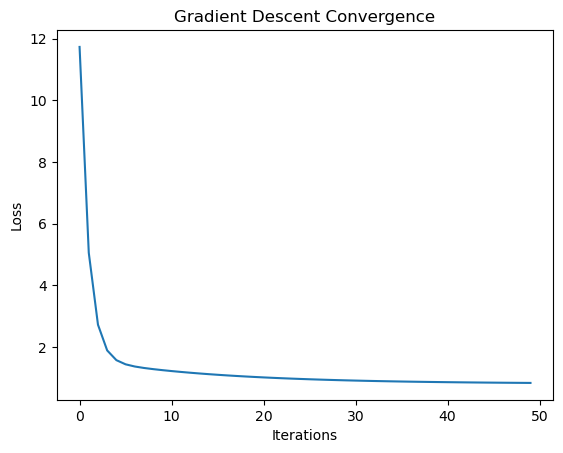

In [6]:
# Plotting the loss curve
plt.plot(losses_gd)
plt.title("Gradient Descent Convergence")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

## example:
 let's find a local minimum for the function $f(x) = x^3-2x^2+2$

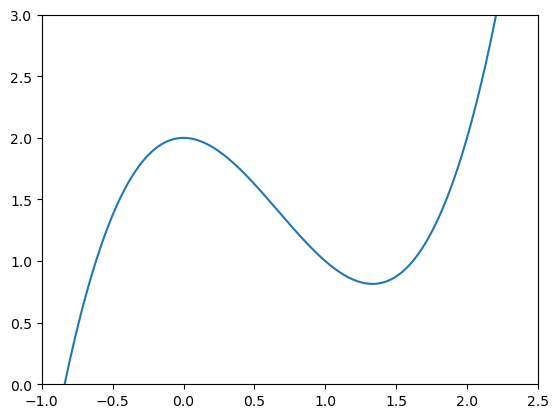

In [7]:
f = lambda x: x**3-2*x**2+2
x = np.linspace(-1,2.5,1000)
plt.plot(x,f(x))
plt.xlim([-1,2.5])
plt.ylim([0,3])
plt.show()

In [8]:
x_old = 0
x_new = 2 # The algorithm starts at x=2
n_k = 0.1 # step size
precision = 0.0001

x_list, y_list = [x_new], [f(x_new)]

# returns the value of the derivative of our function
def f_prime(x):
    return 3*x**2-4*x
 
while abs(x_new - x_old) > precision:
    x_old = x_new
    s_k = -f_prime(x_old)
    x_new = x_old + n_k * s_k
    x_list.append(x_new)
    y_list.append(f(x_new))
print("Local minimum occurs at:", x_new)
print("Number of steps:", len(x_list))

Local minimum occurs at: 1.3334253508453249
Number of steps: 17


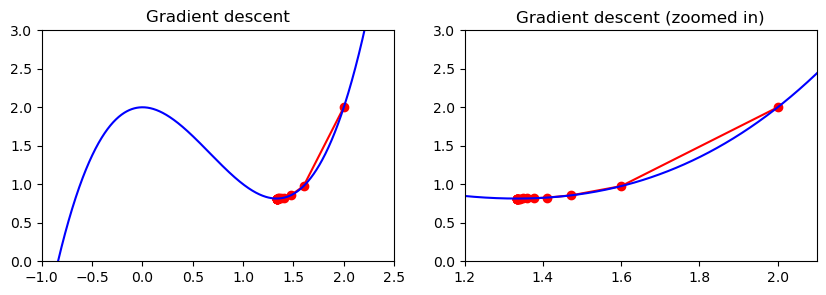

In [9]:
plt.figure(figsize=[10,3])
plt.subplot(1,2,1)
plt.scatter(x_list,y_list,c="r")
plt.plot(x_list,y_list,c="r")
plt.plot(x,f(x), c="b")
plt.xlim([-1,2.5])
plt.ylim([0,3])
plt.title("Gradient descent")
plt.subplot(1,2,2)
plt.scatter(x_list,y_list,c="r")
plt.plot(x_list,y_list,c="r")
plt.plot(x,f(x), c="b")
plt.xlim([1.2,2.1])
plt.ylim([0,3])
plt.title("Gradient descent (zoomed in)")
plt.show()

## Observations : 
learning rate in the implementation above is constant, unlike the algorithm in the pseudocode. Doing this makes it easier to implement the algorithm. However, it also presents some issues: If the step size is too small, then convergence will be very slow, but if we make it too large, then the method may fail to converge at all. 

A solution to this is to use adaptive step sizes as the algorithm (using scipy's fmin function to find optimal step sizes)

## Stochastic Gradient Descent (SGD)

Instead of computing the gradient over the full dataset:
$$\nabla J(\theta) = \frac{1}{n} \sum_{i=1}^{n} \nabla L_i(\theta)$$
SGD approximates it using a single sample:
$$\theta = \theta - \eta \nabla L_i(\theta)$$

---

### Key Difference:
- GD → smooth but slow
- SGD → fast but noisy

In [15]:
theta_sgd = np.random.randn(2, 1)
losses_sgd = []

for epoch in range(50):
    for i in range(len(X_b)):
        random_index = np.random.randint(len(X_b))
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        
        gradients = 2 * xi.T @ (xi @ theta_sgd - yi)
        theta_sgd = theta_sgd - eta * gradients
    
    losses_sgd.append(compute_loss(X_b, y, theta_sgd))

print("Final theta (SGD):", theta_sgd)

Final theta (SGD): [[4.00597696]
 [2.27516959]]


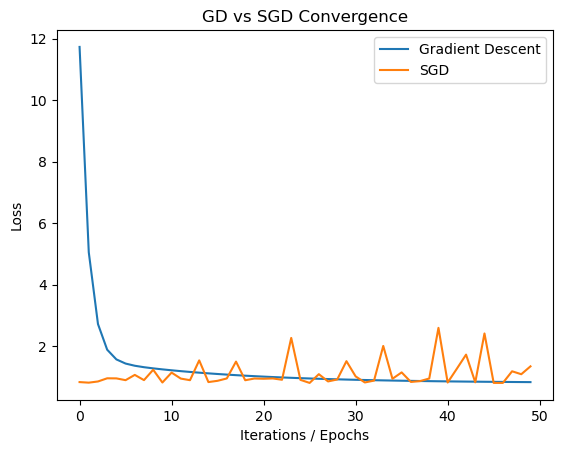

In [16]:
#plot sgd vs gd
plt.plot(losses_gd, label="Gradient Descent")
plt.plot(losses_sgd, label="SGD")
plt.legend()
plt.title("GD vs SGD Convergence")
plt.xlabel("Iterations / Epochs")
plt.ylabel("Loss")
plt.show()

Synthesis: Batch vs. Stochastic Gradient DescentThe fundamental difference between these two algorithms lies in when the model parameters are updated.1. Batch Gradient Descent (BGD)In BGD, you must process the entire dataset of $m$ examples to calculate the average gradient before making a single step.The Math:$$\nabla J(\theta) = \frac{1}{m} \sum_{i=1}^m \nabla L_i(\theta)$$The Catch: For large datasets (e.g., 500,000 points), this is computationally expensive and slow. You make no progress until the very end of the scan.2. Stochastic Gradient Descent (SGD)SGD updates the parameters after looking at each individual item ($i$) in the training set. This allows the model to start improving immediately.The Algorithm:Shuffle the dataset (to avoid bias from data ordering).Iterate through each sample $i = 1$ to $m$.Update parameters immediately using only that sample's error:$$\theta = \theta - \alpha \nabla L_i(\theta)$$

## Conclusion

| Method | Pros | Cons |
|------|------|------|
| Gradient Descent | Stable, smooth | Slow |
| SGD | Fast, scalable | Noisy |

### Key Insight:
- GD uses exact gradient
- SGD uses approximation
- Both converge under proper conditions

---

## Final Thought

In practice, **Mini-batch SGD** is the most commonly used method in deep learning.